# Baseline 2 — XGBoost on all node features

Gradient-boosted trees on the full 53-feature set **minus the credit spread**
(52 features: leverage/solvency, profitability, liquidity, size, activity,
growth, cash flow, Altman Z, equity market variables, and macro conditions).

This is the strongest model that uses only a firm's **own** information, so it
sets the bar any graph model has to clear — and the gap over the CHS logit shows
how much comes just from more features and nonlinearity.

- class imbalance handled via `scale_pos_weight`, itself tuned over {1, √ratio, ratio}
- NaNs are left as NaN — XGBoost routes missing values natively
- hyperparameters: 20-draw random search at 4q (train 1990–2006 → val 2007–2012),
  then held fixed; tree counts selected per horizon the same way

**Training protocol: walk-forward.** Every model is trained with an expanding
window and annual refit anchors 2007–2025 ([`walk_forward.py`](walk_forward.py)):
the model scoring calendar year Y is fit only on rows whose h-quarter label
window closed before Y began (`datadate ≤ Y-01-01 − horizon days`), per horizon
h = 1..8. Scores therefore exist for 2007+ only, and all of 2007–2025 is
out-of-sample. Scores are cached per model/horizon
(`results/models/wf_scores_<model>.parquet`); delete a cache to retrain.

Labels for h ∈ {1, 4, 8} come from phase4; intermediate horizons are rebuilt
with the identical rule and validated at load time. Each horizon's evaluation
sample is right-censored separately. Reported windows: **val-era 2007–2012**
and **test 2013–2025** (for XGBoost models, hyperparameters and tree counts are
selected on 2007–2012, so treat that window accordingly; 2013+ is untouched by
any selection).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import baseline_utils as bu
import walk_forward as wf

panel = bu.load_panel()
FEATURES = bu.XGB_FEATURES
print(f'{len(FEATURES)} features (53 minus log_credit_spread)')

m4 = bu.horizon_mask(panel, bu.PRIMARY_HORIZON)
pd.DataFrame({
    s: {'rows': int((m4 & (panel['split'] == s)).sum()),
        'defaults_4q': int(panel.loc[m4 & (panel['split'] == s), bu.LABEL_COL].sum())}
    for s in ['train', 'val', 'test']
}).T

52 features (53 minus log_credit_spread)


,rows,defaults_4q
train,608151,2133
val,173027,826
test,322530,1031


In [2]:
# Hyperparameter search (20 draws) at the primary 4q horizon, early stopping on
# val PR-AUC; cached to a trials CSV (delete it to re-run). All walk-forward
# refits reuse the winning configuration — re-tuning at every anchor x horizon
# would be ~150x the search cost, and one configuration keeps the term
# structure and the anchors comparable.
col = bu.label_col(bu.PRIMARY_HORIZON)
m4 = bu.horizon_mask(panel, bu.PRIMARY_HORIZON)
tr4 = panel[m4 & (panel['split'] == 'train')]
va4 = panel[m4 & (panel['split'] == 'val')]

trials_path = bu.RESULTS / 'xgb_node_features_trials.csv'
if trials_path.exists():
    trials_df = pd.read_csv(trials_path).sort_values('val_pr_auc', ascending=False)
    print(f'loaded {len(trials_df)} cached tuning trials from {trials_path.name}')
else:
    trials, _ = bu.xgb_random_search(
        tr4[FEATURES], tr4[col].values, va4[FEATURES], va4[col].values,
        n_iter=20, seed=42)
    trials_df = pd.DataFrame(trials).sort_values('val_pr_auc', ascending=False)
    trials_df.to_csv(trials_path, index=False)
best = trials_df.iloc[0].to_dict()
trials_df.round(4).head(10)

loaded 20 cached tuning trials from xgb_node_features_trials.csv


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_lambda,scale_pos_weight,best_iteration,val_roc_auc,val_pr_auc
0,5,0.0264,20.0,0.7447,0.5438,0.1722,16.8557,320,0.8873,0.1542
1,7,0.0457,50.0,0.9060,0.8174,1.2798,16.8557,170,0.8737,0.1539
2,4,0.0797,50.0,0.9291,0.7217,0.2848,1.0000,88,0.8761,0.1529
3,3,0.1780,50.0,0.9114,0.5973,0.8579,16.8557,154,0.8746,0.1520
4,7,0.0171,5.0,0.6360,0.8612,0.8390,1.0000,252,0.8944,0.1492
5,7,0.1339,50.0,0.7550,0.6442,2.3173,16.8557,30,0.8969,0.1489
6,6,0.0123,50.0,0.8527,0.8790,0.5117,284.1153,918,0.8543,0.1484
7,4,0.0439,20.0,0.8275,0.5699,0.1695,16.8557,275,0.8696,0.1469
8,3,0.0412,20.0,0.9434,0.8487,0.1543,16.8557,457,0.8632,0.1465
9,3,0.0266,10.0,0.6123,0.7184,0.2686,1.0000,611,0.8740,0.1447


In [3]:
# Tree count per horizon (one train/val early-stopping fit each; cached), then
# walk-forward scores for all horizons (cached per horizon, resumable)
n_trees = wf.select_n_trees(panel, 'xgb_node_features', FEATURES, best)
print('trees per horizon:', n_trees)

scores = wf.build_xgb_wf_scores(panel, 'xgb_node_features', FEATURES, best, n_trees)
panel = panel.merge(scores, on=['gvkey', 'datadate'], how='left')
panel = panel.rename(columns={f'xgb_node_features_wf_h{h}': f'score_h{h}'
                              for h in bu.HORIZONS})

trees per horizon: {1: 46, 2: 159, 3: 188, 4: 321, 5: 400, 6: 643, 7: 610, 8: 245}
  xgb_node_features_wf_h1: cached


  xgb_node_features_wf_h2: cached


  xgb_node_features_wf_h3: cached


  xgb_node_features_wf_h4: cached


  xgb_node_features_wf_h5: cached


  xgb_node_features_wf_h6: cached


  xgb_node_features_wf_h7: cached


  xgb_node_features_wf_h8: cached


In [4]:
# Per-horizon metrics on the two out-of-sample windows
def wf_metrics(frame, h):
    mh = bu.horizon_mask(frame, h)
    out = {}
    for s in ['val', 'test']:
        sub = frame[mh & (frame['split'] == s)]
        out[s] = bu.evaluate_scores(sub[bu.label_col(h)].values,
                                    sub[f'score_h{h}'].values)
    return pd.DataFrame(out).T

metrics_by_h = {h: wf_metrics(panel, h) for h in bu.HORIZONS}
for h in bu.HORIZONS:
    m = metrics_by_h[h]
    print(f"h={h}q  test ROC-AUC={m.loc['test', 'roc_auc']:.4f}  "
          f"PR-AUC={m.loc['test', 'pr_auc']:.4f}  ({int(m.loc['test', 'n_pos'])} pos)")
print()
print('primary horizon (4q):')
metrics_by_h[bu.PRIMARY_HORIZON].round(4)

h=1q  test ROC-AUC=0.9662  PR-AUC=0.2352  (171 pos)
h=2q  test ROC-AUC=0.9691  PR-AUC=0.2379  (423 pos)
h=3q  test ROC-AUC=0.9644  PR-AUC=0.2103  (710 pos)
h=4q  test ROC-AUC=0.9580  PR-AUC=0.2206  (1031 pos)
h=5q  test ROC-AUC=0.9521  PR-AUC=0.2211  (1377 pos)
h=6q  test ROC-AUC=0.9438  PR-AUC=0.2144  (1720 pos)
h=7q  test ROC-AUC=0.9367  PR-AUC=0.2050  (2047 pos)
h=8q  test ROC-AUC=0.9225  PR-AUC=0.1824  (2360 pos)

primary horizon (4q):


,n,n_pos,base_rate,roc_auc,pr_auc,capture_top1pct,capture_top5pct,capture_top10pct
val,173027.0,826.0,0.0048,0.9068,0.1533,0.3559,0.6380,0.7433
test,322530.0,1031.0,0.0032,0.9580,0.2206,0.4869,0.7886,0.8700


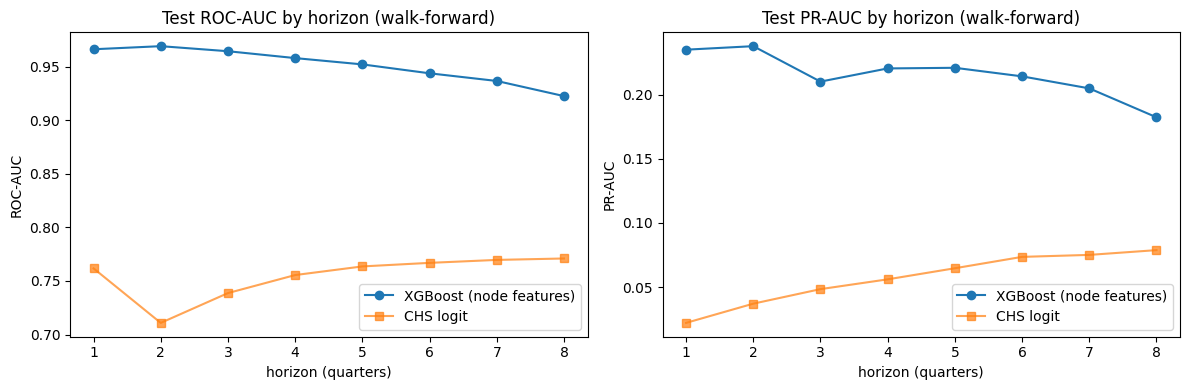

,roc_auc,pr_auc
1,0.9662,0.2352
2,0.9691,0.2379
3,0.9644,0.2103
4,0.9580,0.2206
5,0.9521,0.2211
6,0.9438,0.2144
7,0.9367,0.2050
8,0.9225,0.1824


In [5]:
# Term structure, against the CHS logit (walk-forward)
ts = pd.DataFrame({h: {'roc_auc': metrics_by_h[h].loc['test', 'roc_auc'],
                       'pr_auc': metrics_by_h[h].loc['test', 'pr_auc']}
                   for h in bu.HORIZONS}).T

chs_path = bu.RESULTS / 'chs_logit_metrics.json'
chs_ts = None
if chs_path.exists():
    chs_m = json.load(open(chs_path))['metrics']
    chs_ts = pd.DataFrame({h: {'roc_auc': chs_m[f'h{h}']['test']['roc_auc'],
                               'pr_auc': chs_m[f'h{h}']['test']['pr_auc']}
                           for h in bu.HORIZONS}).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, name in zip(axes, ['roc_auc', 'pr_auc'], ['ROC-AUC', 'PR-AUC']):
    ax.plot(ts.index, ts[metric], marker='o', label='XGBoost (node features)')
    if chs_ts is not None:
        ax.plot(chs_ts.index, chs_ts[metric], marker='s', alpha=0.7, label='CHS logit')
    ax.set_xlabel('horizon (quarters)'); ax.set_ylabel(name); ax.legend()
    ax.set_title(f'Test {name} by horizon (walk-forward)')
plt.tight_layout(); plt.show()
ts.round(4)

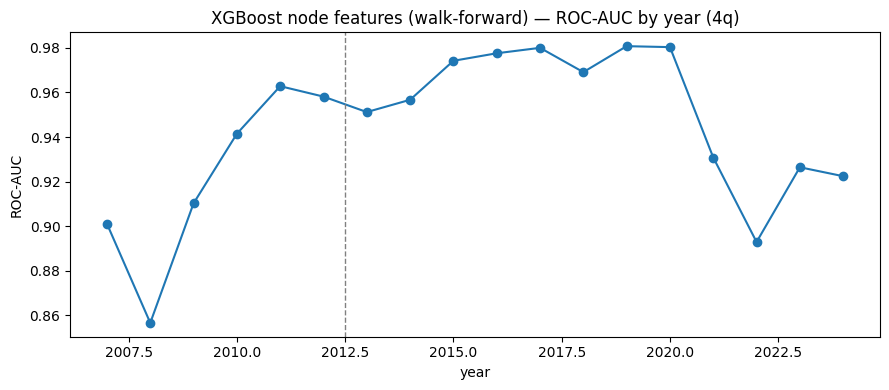

,n,n_pos,roc_auc,pr_auc
2007,30480.0,99.0,0.9010,0.1525
2008,29336.0,307.0,0.8565,0.1938
2009,28551.0,171.0,0.9102,0.1195
2010,28186.0,77.0,0.9415,0.1801
2011,27918.0,88.0,0.9628,0.1211
2012,28556.0,84.0,0.9581,0.1576
2013,29016.0,62.0,0.9512,0.1663
2014,28589.0,64.0,0.9567,0.2261
2015,27669.0,133.0,0.9742,0.4051
2016,26693.0,112.0,0.9776,0.4092


In [6]:
# Year-by-year discrimination at the primary horizon
by_year = bu.evaluate_by_year(panel[bu.horizon_mask(panel, 4)], 'score_h4')
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_year.index, by_year['roc_auc'], marker='o')
ax.axvline(2012.5, color='gray', ls='--', lw=1)
ax.set_title('XGBoost node features (walk-forward) — ROC-AUC by year (4q)')
ax.set_xlabel('year'); ax.set_ylabel('ROC-AUC')
plt.tight_layout(); plt.show()
by_year[['n', 'n_pos', 'roc_auc', 'pr_auc']].round(4)

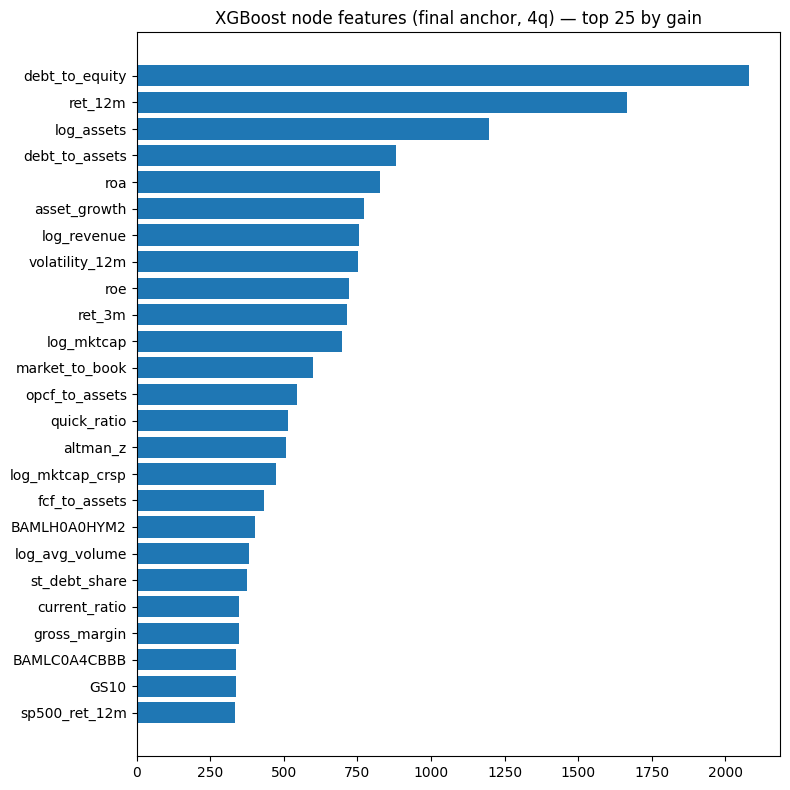

In [7]:
# Representative model for inspection: the final anchor (2025) at 4q —
# trained on everything a 2025 deployment could have seen
import xgboost as xgb

cutoff = wf.embargo_cutoff(wf.ANCHORS[-1], bu.PRIMARY_HORIZON)
tr = panel[(panel['year'] >= wf.TRAIN_START) & (panel['datadate'] <= cutoff)]
final_model = xgb.XGBClassifier(
    n_estimators=n_trees[bu.PRIMARY_HORIZON], tree_method='hist',
    eval_metric='aucpr', n_jobs=-1, random_state=42,
    max_depth=int(best['max_depth']), learning_rate=best['learning_rate'],
    min_child_weight=best['min_child_weight'], subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'], reg_lambda=best['reg_lambda'],
    scale_pos_weight=best['scale_pos_weight'])
final_model.fit(tr[FEATURES], tr[bu.LABEL_COL].values, verbose=False)
final_model.save_model(str(bu.RESULTS / 'xgb_node_features_final_anchor_4q.ubj'))
gain = pd.Series(final_model.get_booster().get_score(importance_type='gain'))
gain = gain.sort_values(ascending=False)

top = gain.head(25)[::-1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index, top.values)
ax.set_title('XGBoost node features (final anchor, 4q) — top 25 by gain')
plt.tight_layout(); plt.show()

In [8]:
score_cols = [f'score_h{h}' for h in bu.HORIZONS]
out = bu.save_results(
    'xgb_node_features',
    {f'h{h}': {s: metrics_by_h[h].loc[s].to_dict() for s in ['val', 'test']}
     for h in bu.HORIZONS},
    predictions=panel[['gvkey', 'datadate', 'split'] + score_cols],
    extra={'protocol': 'walk-forward, annual anchors 2007-2025, label embargo',
           'best_params': {k: best[k] for k in
                           ['max_depth', 'learning_rate', 'min_child_weight',
                            'subsample', 'colsample_bytree', 'reg_lambda',
                            'scale_pos_weight']},
           'n_trees_per_horizon': {str(h): n_trees[h] for h in bu.HORIZONS},
           'n_features': len(FEATURES)},
)
print('saved ->', out)

saved -> /Users/GabrielReisen/Desktop/Credit Contagion Network/results/models/xgb_node_features_metrics.json
